# 99 · Final report: LLM Inference Ops

One self-hosted model (Qwen2.5-7B-Instruct on vLLM), served behind a gateway and a load balancer, measured from a single request on one rented RTX 5090 up to a Kubernetes cluster that shares and autoscales GPUs. Eight phases, eight GPU sessions, about $11 of GPU time.

This notebook pulls the main results of every phase together. **Every number below is computed from the files in `results/`**; the per-phase notebooks (`00` to `07`) have the full detail, and `specification.md` has the hardware and cost of each session.

**Contents**

1. Architecture
2. One request, explained
3. KV cache: what Mooncake changed
4. Reliability: harnesses, traces, evals and failures
5. The journey in one chart
6. Key lessons
7. SLOs and capacity plan
8. What I'd do next

In [1]:
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS = ROOT / "results"
sys.path.insert(0, str(ROOT / "loadtest"))
from compare_tuning import TARGETS, summarize_sweep


def latest(pattern: str) -> dict:
    files = sorted(RESULTS.glob(pattern))
    if not files:
        raise FileNotFoundError(pattern)
    return json.loads(files[-1].read_text())


def ms(x):
    return f"{x * 1000:,.1f} ms" if x < 1 else f"{x:,.2f} s"


print("targets (name, TTFT p95 max s, ITL p50 max s):", TARGETS)
print("result folders:", ", ".join(sorted(p.name for p in RESULTS.iterdir() if p.is_dir())))

targets (name, TTFT p95 max s, ITL p50 max s): [('interactive', 0.5, 0.04), ('relaxed', 1.0, 0.06)]
result folders: 00_setup, 01_end_to_end, 02_kv_cache_mooncake, 03_harnesses_and_traces, 04_breaking_one_gpu, 05_profiling_and_tuning, 06_discarded, 06_scaling_out, 07_gpu_slicing_hami, profiles


## 1. Architecture

The final system, as it ran in Phase 7. Phases 0 to 6 ran the same pieces with Docker Compose on one machine.

```
                         ┌──────────────────────────── one k3s node, 2× RTX 5090 ────────────────────────────┐
 CrewAI agent  ─┐        │                                                                                    │
 Locust        ─┼──────► │ gateway ──► NGINX ──────────► vLLM pod (Qwen2.5-7B, FP8 weights)  GPU 0            │
 curl / client ─┘        │  harnesses   least_conn  └──► vLLM pod (added by KEDA under load) GPU 1            │
                         │  OTel spans  re-resolves                                                           │
 probe (tenant B) ─────► │ ───────────────────────────► vLLM pod (Qwen2.5-1.5B), shares GPU 0 through HAMi    │
                         │                                                                                    │
                         │ Prometheus ◄── gateway, vLLM, GPU exporter, HAMi        Grafana   Jaeger           │
                         │ KEDA ◄── Prometheus query (requests running + waiting per pod)                     │
                         └────────────────────────────────────────────────────────────────────────────────────┘
```

| Layer | What it does | Where it is |
|---|---|---|
| CrewAI agent | A three step agent (analyst, writer, reviewer) that makes realistic multi call traffic | `agent/` |
| Gateway (FastAPI) | Auth, rate limits, token budgets, prompt injection checks, time limits, streaming, metrics, traces | `gateway/` |
| NGINX | Spreads requests across vLLM servers (least connections), retries a dead server, finds new ones by DNS | `nginx/` |
| vLLM | Batches requests on the GPU, manages the KV cache, streams tokens | `vllm/configs/` |
| Mooncake | A KV cache tier in CPU memory, shared between servers (tested in Phases 2 and 6) | `vllm/mooncake/` |
| Prometheus, Grafana, Jaeger | Metrics, the dashboard (38 panels), and traces that follow one request through every layer | `observability/` |
| Locust, probe | Step load tests with a realistic mix, and a steady latency probe for a second tenant | `loadtest/` |
| k3s, HAMi, KEDA | Kubernetes, GPU sharing with memory limits, and autoscaling on vLLM's queue | `scripts/setup_k3s.sh`, `scripts/k8s_manifests.py` |

## 2. One request, explained (Phase 1)

One request at a time, timed at every layer: the client's clock, the gateway's log, NGINX's log, and vLLM's own metrics before and after the request. Medians of 5 runs each.

In [2]:
trace = latest("01_end_to_end/*_trace_single_requests.json")["metrics"]["summary"]
layers = ["client_to_gateway_s", "gateway_s", "nginx_s", "vllm_api_server_s",
          "engine_queue_s", "engine_prefill_s", "engine_decode_s", "engine_other_s"]
names = {"client_to_gateway_s": "client ↔ gateway", "gateway_s": "gateway", "nginx_s": "NGINX",
         "vllm_api_server_s": "vLLM API server", "engine_queue_s": "engine queue",
         "engine_prefill_s": "prefill", "engine_decode_s": "decode", "engine_other_s": "engine other"}
print(f"{'layer':<18}" + "".join(f"{k:>16}" for k in trace))
for layer in layers:
    print(f"{names[layer]:<18}" + "".join(f"{ms(trace[k]['layers_p50_s'][layer]):>16}" for k in trace))
print(f"{'end to end':<18}" + "".join(f"{ms(trace[k]['e2e_s']['p50']):>16}" for k in trace))
for k, t in trace.items():
    l = t["layers_p50_s"]
    outside = l["client_to_gateway_s"] + l["gateway_s"] + l["nginx_s"] + l["vllm_api_server_s"]
    print(f"{k}: decode {l['engine_decode_s'] / t['e2e_s']['p50']:.1%} of end to end, "
          f"everything outside the engine {outside * 1000:.1f} ms")

agent = [json.loads(p.read_text())["metrics"] for p in sorted(RESULTS.glob("01_end_to_end/*_agent_run.json"))]
print(f"\nCrewAI agent, {len(agent)} runs:", ", ".join(f"{a['total_s']:.2f} s ({a['llm_calls']} LLM calls)" for a in agent))

layer                  short_qa_05    summarize_01     long_gen_02
client ↔ gateway            1.0 ms          1.0 ms          1.0 ms
gateway                     1.0 ms          1.1 ms          0.6 ms
NGINX                       0.0 ms          0.0 ms          0.0 ms
vLLM API server             0.7 ms          0.8 ms          1.2 ms
engine queue                0.0 ms          0.0 ms          0.0 ms
prefill                    12.3 ms         12.5 ms         12.2 ms
decode                    601.6 ms          1.63 s          7.33 s
engine other                1.4 ms          2.1 ms          1.6 ms
end to end                618.0 ms          1.65 s          7.35 s
short_qa_05: decode 97.3% of end to end, everything outside the engine 2.7 ms
summarize_01: decode 98.9% of end to end, everything outside the engine 2.8 ms
long_gen_02: decode 99.8% of end to end, everything outside the engine 2.7 ms

CrewAI agent, 3 runs: 8.16 s (3 LLM calls), 8.07 s (3 LLM calls), 8.05 s (3 LLM calls)


**Decode is the request.** At about 9.5 ms per output token on this GPU, generating tokens takes 97 to 99.8% of the time. The gateway, NGINX and the HTTP hops add under 3 ms together, and the agent spends 96% of its time waiting on token generation. So every later phase is about making the GPU produce more tokens at once, not about the layers around it.

## 3. KV cache: what Mooncake changed (Phases 2 and 6)

**Phase 2, one server, low load.** 48 long documents (286k tokens of KV, bigger than the 209k token GPU cache) sent one at a time, then sent again. Without Mooncake, the second visit finds nothing cached and recomputes everything.

In [3]:
kv = {name: latest(f"02_kv_cache_mooncake/*_kv_experiment_{name}.json")["metrics"]["summary"] for name in ("baseline", "mooncake")}
print(f"{'round':<9}{'':<10}{'TTFT p50':>10}{'from GPU':>10}{'from Mooncake':>15}")
for rnd in ("fill", "revisit", "hot"):
    for name in ("baseline", "mooncake"):
        r = kv[name][rnd]
        print(f"{rnd:<9}{name:<10}{r['ttft_s']['p50'] * 1000:>8.0f}ms{r['gpu_hit_ratio']:>10.1%}{r['mooncake_hit_ratio']:>15.1%}")

round                TTFT p50  from GPU  from Mooncake
fill     baseline       438ms      0.3%           0.0%
fill     mooncake       669ms      0.3%           0.0%
revisit  baseline       437ms      0.3%           0.0%
revisit  mooncake       171ms      0.3%          99.5%
hot      baseline        61ms     99.8%           0.0%
hot      mooncake        55ms     99.8%           0.0%


**Phase 6, two servers sharing one Mooncake store, under load.** The conversation workload (each user discusses a long document for six turns), round robin, with and without the shared store.

In [4]:
print(f"{'users':>6}{'without: tok/s':>16}{'TTFT p95':>10}{'with Mooncake: tok/s':>22}{'TTFT p95':>10}{'preemptions':>13}")
rr = {s["users"]: s for s in latest("06_scaling_out/*_load_sweep_lb_round_robin.json")["metrics"]["steps"]}
mc = {s["users"]: s for s in latest("06_scaling_out/*_load_sweep_lb_round_robin_mooncake.json")["metrics"]["steps"]}
for u in sorted(rr):
    a, b = rr[u], mc.get(u, {})
    pre = b.get("server", {}).get("preemptions")
    print(f"{u:>6}{a['server']['output_tokens_per_s']:>16,.0f}{a['ttft_s']['p95']:>9.1f}s"
          f"{b['server']['output_tokens_per_s']:>22,.0f}{b['ttft_s']['p95']:>9.1f}s{(pre or 0):>13,.0f}")

 users  without: tok/s  TTFT p95  with Mooncake: tok/s  TTFT p95  preemptions
   256           6,401      0.6s                 4,217     29.5s          507
   512           5,390     11.8s                 1,840     27.7s          783


**Mooncake helps exactly one pattern and hurts another.** A long prompt that comes back after being evicted from the GPU loads 2.6× faster from Mooncake than it recomputes (171 vs 437 ms), and it pays for itself after about one revisit. But under concurrent load over plain TCP, vLLM keeps each block in GPU memory until it's saved to the store, the saves can't keep up, and the waiting blocks crowd out running requests: throughput fell by a third to two thirds. **Without RDMA, use it for long, reused prompts at modest load, not as a general speedup.**

## 4. Reliability: harnesses, traces, evals and failures

### Harnesses (Phase 3)

The same 22 eval cases with the gateway's checks on and off.

In [5]:
on = latest("03_harnesses_and_traces/*_evals_harnesses_on.json")["metrics"]["summary"]
off = latest("03_harnesses_and_traces/*_evals_harnesses_off.json")["metrics"]["summary"]
print(f"{'':<22}{'harnesses on':>14}{'harnesses off':>15}")
print(f"{'passed':<22}{on['passed']:>11}/{on['total']}{off['passed']:>12}/{off['total']}")
for cat in on["by_category"]:
    a, b = on["by_category"][cat], off["by_category"][cat]
    print(f"{'  ' + cat:<22}{a['passed']:>11}/{a['total']}{b['passed']:>12}/{b['total']}")
print(f"{'secrets leaked':<22}{on['secrets_leaked']:>14}{off['secrets_leaked']:>15}")
print(f"{'GPU time, all cases':<22}{on['gpu_s_total']:>13.1f}s{off['gpu_s_total']:>14.1f}s")

drills = latest("03_harnesses_and_traces/*_failure_drills.json")["metrics"]
print(f"\nfailure drills: {drills['passed']}/{drills['total']} passed")
for d in drills["drills"]:
    print(f"  {d['drill']:<22}{'pass' if d['passed'] else 'FAIL':<6}{d['expected']}")

                        harnesses on  harnesses off
passed                         20/22          16/22
  correctness                   7/7           7/7
  instructions                  4/5           4/5
  summarization                 0/1           0/1
  safety                        3/3           3/3
  harness                       6/6           2/6
secrets leaked                     0              2
GPU time, all cases            17.3s          24.1s

failure drills: 6/6 passed
  injection             pass  400 prompt_injection, no GPU work
  oversized             pass  413 prompt_too_long, no GPU work
  rate_limit            pass  ~60 allowed (plus what refills during the burst), the rest 429 with Retry-After
  timeout               pass  stream ends at ~2 s with a timeout event; vLLM stops well short of 1000 tokens
  disconnect            pass  client hangs up at ~1 s; vLLM stops generating soon after
  vllm_down             pass  fast 502 while vLLM is down; traffic recovers on i

### Quality under tuning (Phase 5)

Every throughput change was checked against the same eval set before being recommended.

In [6]:
qual = {}
for label in ("baseline", "tune_fp8_weights", "tune_kv_cache_fp8", "tuned"):
    q = latest(f"05_profiling_and_tuning/*_evals_quality_{label}.json")["metrics"]["summary"]
    sweep = latest(f"05_profiling_and_tuning/*_load_sweep_{label}.json")
    peak = sweep["metrics"]["breaking_points"]["peak_output_tokens_per_s"]
    qual[label] = (q["passed"], q["total"], peak)
base_peak = qual["baseline"][2]
print(f"{'config':<20}{'evals':>8}{'peak tok/s':>12}{'vs baseline':>13}")
for label, (p, t, peak) in qual.items():
    print(f"{label:<20}{p:>5}/{t}{peak:>12,.0f}{peak / base_peak - 1:>+12.0%}")

config                 evals  peak tok/s  vs baseline
baseline               21/22       5,794         +0%
tune_fp8_weights       21/22       8,662        +50%
tune_kv_cache_fp8      17/22       7,064        +22%
tuned                  15/22      11,513        +99%


### Failures under load (Phases 6 and 7)

In [7]:
fo = latest("06_scaling_out/*_timeline_failover.json")["metrics"]
print(f"failover, one of two servers stopped under load: {fo['errors']} errors of {fo['requests']:,} requests "
      f"({fo['errors'] / fo['requests']:.1%}), all in the 10 s of the stop")
errs = [b for b in fo["timeline"] if b["errors"]]
print("  error buckets:", [(b["t_s"], b["errors"]) for b in errs])

auto = latest("07_gpu_slicing_hami/*_timeline_autoscale.json")["metrics"]
print(f"autoscale 1 → 2 → 1 pods: {auto['errors']} errors of {auto['requests']:,} requests "
      f"({auto['errors'] / auto['requests']:.1%}), all at the scale down")

failover, one of two servers stopped under load: 127 errors of 15,906 requests (0.8%), all in the 10 s of the stop
  error buckets: [(50, 127)]
autoscale 1 → 2 → 1 pods: 32 errors of 30,250 requests (0.1%), all at the scale down


**What caught what.** The harnesses stopped every bad request in about a third of a millisecond (p50), and without them the model leaked a secret *while refusing to reveal it*. The eval set caught the FP8 KV cache and the combined config getting arithmetic and JSON wrong, which would otherwise have been the recommended "+99%" result. Traces followed one agent task from the agent through the gateway and NGINX into vLLM's scheduler. Under load, the only errors were requests already streaming from a server that stopped: a crash (Phase 6) or a scale down that killed a pod after its 30 s grace period (Phase 7). Two real incidents were caught by the dashboard, not by luck: NGINX benching both healthy servers (Phase 6) and HAMi's renamed metrics (Phase 7).

## 5. The journey in one chart

Each stage on the same traffic (Phase 4's mix: short questions, conversations, summaries and long answers, closed loop) and the same **interactive SLO: TTFT p95 ≤ 0.5 s and ITL p50 ≤ 40 ms**. Capacity is the highest user step that met it.

Hosts and prices differed between sessions ($0.60 to $1.33 per GPU hour), so cost is shown at one **reference price of $1.00 per GPU hour**: multiply by your own price. The price actually paid is in the last column.

stage                            GPUs users @SLO  tok/s @SLO  peak tok/s  $/1M @ $1/GPU h  $/1M as paid
1. baseline, 1 GPU (BF16)           1        128       5,546       5,794           0.0501        0.0607
2. FP8 weights, 1 GPU               1        128       8,264       8,662           0.0336        0.0407
3. 2 copies behind NGINX            2        256      16,022      16,022           0.0347        0.0206
4. k3s: 7B and 1.5B, a GPU each     2       256+       7,664       7,873           0.0725        0.0522
5. HAMi: 7B + 1.5B on 1 GPU         1        128       3,964       3,964           0.0701        0.0504
+ = met the SLO at the highest step tested, so the real limit is higher


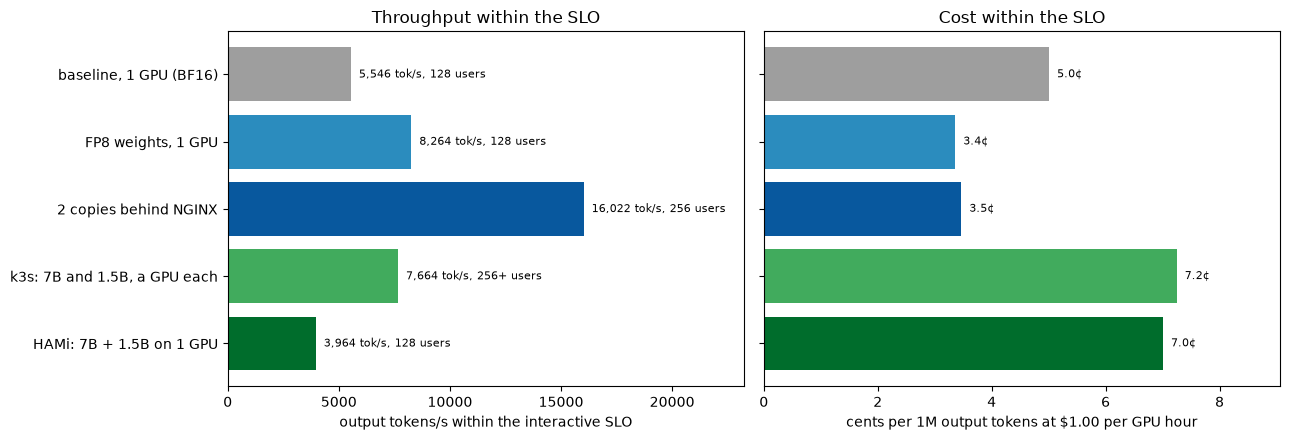

In [8]:
REF_PRICE_PER_GPU_HOUR = 1.00
STAGES = [  # (stage, results file, GPUs, price actually paid per hour for the machine)
    ("1. baseline, 1 GPU (BF16)",      "05_profiling_and_tuning/*_load_sweep_baseline.json",         1, 1.211),
    ("2. FP8 weights, 1 GPU",          "05_profiling_and_tuning/*_load_sweep_tune_fp8_weights.json", 1, 1.211),
    ("3. 2 copies behind NGINX",       "06_scaling_out/*_load_sweep_scale_2x.json",                  2, 1.190),
    ("4. k3s: 7B and 1.5B, a GPU each","07_gpu_slicing_hami/*_load_sweep_isolated.json",             2, 1.439),
    ("5. HAMi: 7B + 1.5B on 1 GPU",    "07_gpu_slicing_hami/*_load_sweep_shared.json",               1, 1.439 / 2),
]
journey = []
for name, pattern, gpus, paid in STAGES:
    run = latest(pattern)
    s = summarize_sweep(run, REF_PRICE_PER_GPU_HOUR * gpus)
    cap = s["capacity"]["interactive"]
    top = max(st["users"] for st in run["metrics"]["steps"])
    journey.append({"stage": name, "gpus": gpus, "users": cap["users"], "capped": cap["users"] == top,
                    "tps": cap["output_tokens_per_s"], "peak": s["peak_output_tokens_per_s"],
                    "ref_cost": cap["usd_per_million_output_tokens"],
                    "paid_cost": paid / (cap["output_tokens_per_s"] * 3600) * 1e6})

print(f"{'stage':<32}{'GPUs':>5}{'users @SLO':>11}{'tok/s @SLO':>12}{'peak tok/s':>12}{'$/1M @ $1/GPU h':>17}{'$/1M as paid':>14}")
for j in journey:
    users = f"{j['users']}{'+' if j['capped'] else ''}"
    print(f"{j['stage']:<32}{j['gpus']:>5}{users:>11}{j['tps']:>12,.0f}{j['peak']:>12,.0f}{j['ref_cost']:>17.4f}{j['paid_cost']:>14.4f}")
print("+ = met the SLO at the highest step tested, so the real limit is higher")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
labels = [j["stage"].split(". ", 1)[1] for j in journey]
colors = ["#9e9e9e", "#2b8cbe", "#08589e", "#41ab5d", "#006d2c"]
ax1.barh(labels, [j["tps"] for j in journey], color=colors)
for i, j in enumerate(journey):
    ax1.text(j["tps"], i, f"  {j['tps']:,.0f} tok/s, {j['users']}{'+' if j['capped'] else ''} users", va="center", fontsize=8)
ax1.invert_yaxis(); ax1.set_xlabel("output tokens/s within the interactive SLO"); ax1.set_xlim(0, max(j["tps"] for j in journey) * 1.45)
ax1.set_title("Throughput within the SLO")
ax2.barh(labels, [j["ref_cost"] * 100 for j in journey], color=colors)
for i, j in enumerate(journey):
    ax2.text(j["ref_cost"] * 100, i, f"  {j['ref_cost'] * 100:.1f}¢", va="center", fontsize=8)
ax2.invert_yaxis(); ax2.set_yticklabels([]); ax2.set_xlabel("cents per 1M output tokens at $1.00 per GPU hour")
ax2.set_xlim(0, max(j["ref_cost"] for j in journey) * 100 * 1.25); ax2.set_title("Cost within the SLO")
plt.tight_layout(); plt.show()

**Reading the chart.**

* **Baseline → FP8 weights:** the same GPU produces 49% more tokens within the SLO, and each token costs a third less. Phase 5's profile showed why: three quarters of GPU time is spent multiplying by the weights, and FP8 halves their size.
* **1 → 2 GPUs:** two independent copies behind NGINX doubled the users served (128 → 256) at the same cost per token, 92% scaling efficiency at the peak.
* **Kubernetes, a GPU per model:** the 7B model on one GPU and a small 1.5B model (4 clients) on the other, the usual way to run two models. The second GPU does almost nothing, so the 7B model's cost per token more than doubles compared with stage 2. (The 7B sweep stopped at 256 users and still met the SLO there, so its real capacity is higher than shown.)
* **HAMi:** both models on *one* GPU. The two take turns on the GPU, so the 7B model gets about half of it: 128 users within the SLO, while the small model keeps ~22 ms time to first token. The 7B model's cost per token is the same as stage 4 (7.0 vs 7.2 cents) with **half the GPUs**. HAMi doesn't make tokens cheaper, it stops a small model from occupying a whole GPU.
* **Mooncake isn't a bar** because it was measured on a different workload (conversations) and made that workload slower; see section 3.

## 6. Key lessons

1. **Decode is the request, and the weights are the decode.** One request is 97 to 99.8% decode (Phase 1), and three quarters of GPU time under load is matrix multiplies against the weights (Phase 5). FP8 weights gave +50% peak throughput and tokens a third cheaper within the SLO, with the same eval results as BF16. That was the biggest single gain in the project.

2. **The first break was a default, not the hardware.** One RTX 5090 broke at 384 users because vLLM caps running requests at 256 on GPUs under 70 GB, while the KV cache was only 53% full. Time to first token went from 0.5 s to 5.8 s the moment the queue formed, with zero errors: an overloaded LLM server doesn't fail, it gets slow.

3. **Every speedup has to pass the evals.** The FP8 KV cache (+22%) and the combined config (+99%) both looked like wins and both broke the model: 17 × 23 = "253", broken JSON, and a phishing request it no longer refused. Without the 22 case eval set, the broken config would have been the recommendation.

4. **Scale with copies and route by load, not by count.** Two copies scaled 1.84× (92%). Tensor parallel across the same two GPUs was 13× slower, because consumer cards without NVLink or peer to peer send every all reduce through host memory. Least connections beat round robin by ~10× on tail latency (1.2 s vs 12 s TTFT p95) because requests differ wildly in length.

5. **The parts between the GPUs cause the outages.** NGINX's defaults benched two healthy servers (1,574 errors) because it held idle connections longer than vLLM did. A shared Mooncake store over TCP cut throughput by up to two thirds. A Kubernetes scale down cut 32 streams. Each one was visible within seconds on the dashboard or in the load test's per request log, which is the case for building observability first.

## 7. SLOs and capacity plan

**The recommended deployment:** Qwen2.5-7B-Instruct with FP8 weights, one copy per RTX 5090, behind NGINX with least connections, the gateway's harnesses on, autoscaled by KEDA on requests inside vLLM. Small side models share a GPU through HAMi.

| SLO | Definition | Users per GPU (measured) |
|---|---|---|
| Interactive | TTFT p95 ≤ 0.5 s, ITL p50 ≤ 40 ms (25+ tokens/s per stream) | 128 |
| Relaxed | TTFT p95 ≤ 1 s, ITL p50 ≤ 60 ms (16+ tokens/s per stream) | 192 |

A "user" here is a Locust user with no think time: a stream that sends its next request the moment the last one finishes. It's the right unit for sizing a GPU (concurrent requests in flight), and a real person reading answers between requests is a fraction of one.

In [9]:
two = summarize_sweep(latest("06_scaling_out/*_load_sweep_scale_2x.json"), 1.0)
per_gpu = {name: two["capacity"][name]["users"] / 2 for name, _, _ in TARGETS}
tps_per_gpu = two["capacity"]["interactive"]["output_tokens_per_s"] / 2
print("measured on 2 GPUs (Phase 6), per GPU:", per_gpu, f"| {tps_per_gpu:,.0f} output tokens/s per GPU at the interactive SLO")

HOURS_PER_MONTH = 730
PRICES = {"market ($0.72/GPU h, Phase 7)": 0.72, "secure cloud ($1.33/GPU h, Phase 0)": 1.327}
print(f"\nInteractive SLO, one spare GPU for failover and for the ~2.5 min it takes a new pod to load")
print(f"{'concurrent streams':>19}{'GPUs':>6}" + "".join(f"{k:>38}" for k in PRICES) + f"{'output tokens/month':>22}")
for n in (100, 500, 1_000, 5_000, 10_000):
    gpus = math.ceil(n / per_gpu["interactive"]) + 1
    cost = "".join(f"{'$' + format(gpus * p * HOURS_PER_MONTH, ',.0f') + '/month':>38}" for p in PRICES.values())
    tokens = min(n / per_gpu["interactive"], gpus - 1) * tps_per_gpu * 3600 * HOURS_PER_MONTH
    print(f"{n:>19,}{gpus:>6}{cost}{tokens / 1e9:>19,.1f} B")

measured on 2 GPUs (Phase 6), per GPU: {'interactive': 128.0, 'relaxed': 192.0} | 8,011 output tokens/s per GPU at the interactive SLO

Interactive SLO, one spare GPU for failover and for the ~2.5 min it takes a new pod to load
 concurrent streams  GPUs         market ($0.72/GPU h, Phase 7)   secure cloud ($1.33/GPU h, Phase 0)   output tokens/month
                100     2                          $1,051/month                          $1,937/month               16.4 B
                500     5                          $2,628/month                          $4,844/month               82.2 B
              1,000     9                          $4,730/month                          $8,718/month              164.5 B
              5,000    41                         $21,550/month                         $39,717/month              822.4 B
             10,000    80                         $42,048/month                         $77,497/month            1,644.7 B


At full use, an RTX 5090 within the interactive SLO produces about 8,000 output tokens a second, about 29 million an hour, at roughly **2.5 to 4.6 cents per million output tokens** depending on the host's price. Two things the plan builds in: a spare GPU, because a crash costs only the requests in flight but halves capacity until the server is back (~70 s), and early scale out, because a new vLLM pod took 139 s to become ready while latency climbed.

## 8. What I'd do next

* **Fix the scale down.** Give vLLM pods a `terminationGracePeriodSeconds` longer than the longest answer and a `preStop` wait, so a pod leaves the Service before it stops. That removes the only errors in the autoscale run.
* **Four GPUs and a second node.** The scaling curve stops at 2 GPUs because no 4 GPU VM was available. The script is ready (`PHASE6_DIR=06_scaling_out_4gpu SCALES="1 2 4"`).
* **Mooncake over RDMA.** The TCP results say the store's write path is the bottleneck; RDMA is what Mooncake was designed for, and disaggregated prefill and decode needs a vLLM version without the scheduler assertion it hit.
* **A calibrated FP8 KV cache.** It doubled KV capacity; with calibrated scales instead of the defaults it might keep answer quality.
* **Real user traffic.** Think time between requests, a long tail of prompt lengths, and per tenant SLOs, so the capacity plan is in users rather than concurrent streams.
* **A bigger model.** A 32B or 70B model in FP8 or 4 bit would make tensor parallel necessary, which needs GPUs with NVLink or at least peer to peer.

## Phase 8 exit criteria

- [x] One notebook that pulls every phase together, computed from `results/`
- [x] The journey from one GPU to a shared, autoscaled cluster on the same SLO
- [x] Key lessons, a capacity plan with monthly cost, and next steps
- [x] A README with a two minute summary and the headline numbers